This Notebook is an Implementation of the P300NN Demonstrating the impact of Adding the Preprocessing Pipeline and the Class Balancing/Weighting 

In [1]:
import mne
import numpy as np
from numpy import matlib as mb
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import warnings
from sklearn import metrics
from collections import defaultdict
import regex as re
from sklearn.metrics import accuracy_score
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
from sklearn.metrics import roc_auc_score
from models.P300NN import P300NNClassifier
from models.P300NN_noClassBalance import P300NNClassifierNCB
from src.Dataset import Dataset
from src.Speller import Speller
warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("WARNING")
import tensorflow as tf
print("GPUs available:", tf.config.list_physical_devices('GPU'))
print("CPUs available:", tf.config.list_physical_devices('CPU'))
print("TF use:", tf.test.gpu_device_name() if tf.test.gpu_device_name() else "CPU")

/home/users/ag796/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/users/ag796/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/home/users/ag796/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
I0000 00:00:1777086823.885282 2283732 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical result

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
TF use: /device:GPU:0


I0000 00:00:1777086830.049058 2283732 gpu_device.cc:2043] Created device /device:GPU:0 with 20849 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:17:00.0, compute capability: 8.6
I0000 00:00:1777086830.055872 2283732 gpu_device.cc:2043] Created device /device:GPU:0 with 20849 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:17:00.0, compute capability: 8.6


Divide and Separate Training and Testing Paths

In [2]:
def group_paths_by_participant(data_paths):
    participant_files = defaultdict(lambda: {'train': [], 'test': []})
    for path in data_paths:
        parts = path.split(os.sep)
        participant_id = parts[6]

        if 'Train' in path or 'train' in path:
            participant_files[participant_id]['train'].append(path)
        elif 'Test' in path or 'test' in path:
            participant_files[participant_id]['test'].append(path)
        else:
            print(f"Unclassified path: {path}")

    return participant_files


In [3]:
important_channels = ['EEG_Fz', 'EEG_Cz', 'EEG_Pz', 'EEG_P3',
                      'EEG_PO7', 'EEG_PO8', 'EEG_P4', 'EEG_Oz']

#first using default values
ds = Dataset(
    glob_path=os.path.join(project_root, "data", "*", "*", "*", "CB", "*"),
    tmin=0,
    tmax=0.8, 
)

participant_files = group_paths_by_participant(ds.data_paths)
participants = list(participant_files.keys())

In [8]:
#With Filtering

studyL_results = []

# Loop through all participants
for participant_id in participant_files.keys():

    print(f"\nProcessing participant {participant_id}")

    train_files = participant_files[participant_id]['train']
    test_files  = participant_files[participant_id]['test']

    X_train, y_train = [], []
    X_test, y_test   = [], []

    # Load train data
    for path in train_files:
        ds = Dataset(
            path,
            important_channels=important_channels,
            sample_rate=256,
            tmin=0,
            tmax=0.8,
            use_car=True, 
            notch_filter=True
        )
        X, y = ds[0]
        X_train.append(X)
        y_train.append(y)

    # Load test data
    for path in test_files:
        ds = Dataset(
            path,
            important_channels=important_channels,
            sample_rate=256,
            tmin=0,
            tmax=0.8,
            use_car=True, 
            notch_filter=True
        )
        X, y = ds[0]
        X_test.append(X)
        y_test.append(y)

    X_train = np.vstack(X_train)
    y_train = np.concatenate(y_train)

    X_test = np.vstack(X_test)
    y_test = np.concatenate(y_test)

    X_train_nn = X_train[..., np.newaxis]
    X_test_nn = X_test[..., np.newaxis]

    # Train on train partition
    p300net = P300NNClassifier()
    p300net.train(X_train_nn, y_train)

    # Test on test partition
    scores = p300net.test(X_test_nn, y_test)
    y_pred = np.argmax(p300net.model.predict(X_test_nn), axis=1)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, scores)

    print(f"Participant {participant_id} P300net Accuracy: {acc:.3f}, AUC: {auc:.3f}")

    # Decode and predict characters
    character_accuracies = []
    for path in test_files:
        ds = Dataset(
            path,
            important_channels=important_channels,
            sample_rate=256,
            tmin=0,
            tmax=0.8, 
            notch_filter=True, 
            use_car=True
        )
        X_test_specific, y_test_specific = ds[0]
        X_test_specific_nn = X_test_specific[..., np.newaxis]

        probs = p300net.model.predict(X_test_specific_nn)
        scores_specific = probs[:, 1] - probs[:, 0]

        # Speller implementation
        raw = ds.raw
        epochs = ds.epochs
        char_ch_names = [ch for ch in raw.ch_names if re.match(r'^[A-Za-z0-9]+_\d+_\d+$', ch)]
        char_ch_indices = [raw.ch_names.index(ch) for ch in char_ch_names]

        curr_target_idx = raw.ch_names.index('CurrentTarget')
        phase_idx = raw.ch_names.index('PhaseInSequence')
        data = raw.get_data()
        stim_indices = np.where(data[phase_idx] == 2)[0]
        changes = np.diff(data[curr_target_idx], prepend=data[curr_target_idx][0]-1)
        target_onsets = stim_indices[np.isin(stim_indices, np.where(changes != 0)[0])]
        target_codes = data[curr_target_idx][target_onsets].astype(int)
        current_target_events = np.array([[onset, 0, code] for onset, code in zip(target_onsets, target_codes)])

        pcr = {
            'epochs': epochs,
            'raw_data': raw,
            'character_channels': char_ch_indices,
            'current_target_events': current_target_events
        }

        speller_grid = [
            "A","B","C","D","E","F","G","H","I","J","K","L","M",
            "N","O","P","Q","R","S","T","U","V","W","X","Y","Z",
            "_","1","2","3","4","5","6","7","8","9"
        ]
        speller = Speller(speller_grid)

        predictions = speller.run(pcr, clf=None, X=scores_specific, y=1)
        metrics = speller.get_metrics()
        character_accuracies.append(metrics['accuracy'])

    avg_char_acc = np.mean(character_accuracies)
    print(f"Average character accuracy: {avg_char_acc:.3f}")

    # Store results
    studyL_results.append({
        "participant": participant_id,
        "p300net_accuracy": acc,
        "p300net_auc": auc,
        "characcuracy": avg_char_acc,
    })

# Summary DataFrame
results_df = pd.DataFrame(studyL_results)
print("\nStudy L Summary")
print(results_df)
print("Average AUC:", results_df["p300net_auc"].mean())
print("Average Model Accuracy:", results_df["p300net_accuracy"].mean())
print("Average Character Accuracy:", results_df["characcuracy"].mean())


Processing participant L_01
Epoch 1/3000


I0000 00:00:1777088006.050242 2284326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_576885__.48
I0000 00:00:1777088009.611528 2284326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_576885__.48


119/119 - 9s - 75ms/step - accuracy: 0.8870 - loss: 0.3681
Epoch 2/3000
119/119 - 3s - 28ms/step - accuracy: 0.8889 - loss: 0.3586
Epoch 3/3000
119/119 - 0s - 3ms/step - accuracy: 0.8889 - loss: 0.3398
Epoch 4/3000
119/119 - 1s - 6ms/step - accuracy: 0.8892 - loss: 0.3341
Epoch 5/3000
119/119 - 0s - 3ms/step - accuracy: 0.8889 - loss: 0.3287
Epoch 6/3000
119/119 - 0s - 4ms/step - accuracy: 0.8892 - loss: 0.3246
Epoch 7/3000
119/119 - 1s - 6ms/step - accuracy: 0.8897 - loss: 0.3274
Epoch 8/3000
119/119 - 0s - 4ms/step - accuracy: 0.8897 - loss: 0.3260
Epoch 9/3000
119/119 - 1s - 6ms/step - accuracy: 0.8907 - loss: 0.3226
Epoch 10/3000
119/119 - 0s - 4ms/step - accuracy: 0.8905 - loss: 0.3193
Epoch 11/3000
119/119 - 0s - 4ms/step - accuracy: 0.8915 - loss: 0.3182
Epoch 12/3000
119/119 - 0s - 4ms/step - accuracy: 0.8923 - loss: 0.3198
Epoch 13/3000
119/119 - 0s - 4ms/step - accuracy: 0.8897 - loss: 0.3151
Epoch 14/3000
119/119 - 0s - 4ms/step - accuracy: 0.8905 - loss: 0.3157
Epoch 15/300

I0000 00:00:1777088031.536789 2284326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_593376__.48
I0000 00:00:1777088034.989656 2284325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_593376__.48


119/119 - 9s - 72ms/step - accuracy: 0.8833 - loss: 0.3729
Epoch 2/3000
119/119 - 4s - 30ms/step - accuracy: 0.8889 - loss: 0.3559
Epoch 3/3000
119/119 - 1s - 5ms/step - accuracy: 0.8889 - loss: 0.3536
Epoch 4/3000
119/119 - 0s - 3ms/step - accuracy: 0.8889 - loss: 0.3493
Epoch 5/3000
119/119 - 0s - 3ms/step - accuracy: 0.8889 - loss: 0.3414
Epoch 6/3000
119/119 - 0s - 3ms/step - accuracy: 0.8889 - loss: 0.3374
Epoch 7/3000
119/119 - 0s - 3ms/step - accuracy: 0.8886 - loss: 0.3322
Epoch 8/3000
119/119 - 0s - 3ms/step - accuracy: 0.8889 - loss: 0.3310
Epoch 9/3000
119/119 - 0s - 3ms/step - accuracy: 0.8878 - loss: 0.3246
Epoch 10/3000
119/119 - 1s - 6ms/step - accuracy: 0.8889 - loss: 0.3224
Epoch 11/3000
119/119 - 0s - 3ms/step - accuracy: 0.8894 - loss: 0.3279
Epoch 12/3000
119/119 - 0s - 3ms/step - accuracy: 0.8884 - loss: 0.3205
Epoch 13/3000
119/119 - 0s - 3ms/step - accuracy: 0.8886 - loss: 0.3179
Epoch 14/3000
119/119 - 0s - 3ms/step - accuracy: 0.8899 - loss: 0.3170
Epoch 15/300

...

119/119 - 9s - 78ms/step - accuracy: 0.8886 - loss: 0.3509
Epoch 2/3000
119/119 - 0s - 3ms/step - accuracy: 0.8899 - loss: 0.3268
Epoch 3/3000
119/119 - 0s - 3ms/step - accuracy: 0.8897 - loss: 0.3128
Epoch 4/3000
119/119 - 1s - 6ms/step - accuracy: 0.8939 - loss: 0.2982
Epoch 5/3000
119/119 - 1s - 5ms/step - accuracy: 0.8884 - loss: 0.3046
Epoch 6/3000
119/119 - 1s - 5ms/step - accuracy: 0.8918 - loss: 0.3010
Epoch 7/3000
119/119 - 1s - 5ms/step - accuracy: 0.8913 - loss: 0.2946
Epoch 8/3000
119/119 - 0s - 4ms/step - accuracy: 0.8963 - loss: 0.2900
Epoch 9/3000
119/119 - 1s - 6ms/step - accuracy: 0.8989 - loss: 0.2804
Epoch 10/3000
119/119 - 1s - 5ms/step - accuracy: 0.8960 - loss: 0.2757
Epoch 11/3000
119/119 - 0s - 4ms/step - accuracy: 0.8995 - loss: 0.2777
Epoch 12/3000
119/119 - 1s - 6ms/step - accuracy: 0.9032 - loss: 0.2761
Epoch 13/3000
119/119 - 0s - 4ms/step - accuracy: 0.8974 - loss: 0.2777
Epoch 14/3000
119/119 - 0s - 4ms/step - accuracy: 0.8976 - loss: 0.2709
Epoch 15/3000

I0000 00:00:1777088276.318230 2284325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_786768__.48
I0000 00:00:1777088279.780780 2284325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_786768__.48


119/119 - 9s - 72ms/step - accuracy: 0.8854 - loss: 0.3711
Epoch 2/3000
119/119 - 0s - 3ms/step - accuracy: 0.8889 - loss: 0.3618
Epoch 3/3000
119/119 - 0s - 3ms/step - accuracy: 0.8889 - loss: 0.3514
Epoch 4/3000
119/119 - 0s - 3ms/step - accuracy: 0.8886 - loss: 0.3468
Epoch 5/3000
119/119 - 0s - 3ms/step - accuracy: 0.8889 - loss: 0.3377
Epoch 6/3000
119/119 - 0s - 3ms/step - accuracy: 0.8886 - loss: 0.3385
Epoch 7/3000
119/119 - 0s - 3ms/step - accuracy: 0.8892 - loss: 0.3349
Epoch 8/3000
119/119 - 0s - 3ms/step - accuracy: 0.8881 - loss: 0.3326
Epoch 9/3000
119/119 - 0s - 3ms/step - accuracy: 0.8884 - loss: 0.3335
Epoch 10/3000
119/119 - 0s - 3ms/step - accuracy: 0.8897 - loss: 0.3249
Epoch 11/3000
119/119 - 0s - 3ms/step - accuracy: 0.8886 - loss: 0.3286
Epoch 12/3000
119/119 - 0s - 3ms/step - accuracy: 0.8892 - loss: 0.3247
Epoch 13/3000
119/119 - 0s - 3ms/step - accuracy: 0.8878 - loss: 0.3290
Epoch 14/3000
119/119 - 0s - 3ms/step - accuracy: 0.8899 - loss: 0.3262
Epoch 15/3000

I0000 00:00:1777088294.954068 2284326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_802720__.48
I0000 00:00:1777088298.492272 2284326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_802720__.48


119/119 - 9s - 76ms/step - accuracy: 0.8865 - loss: 0.3467
Epoch 2/3000
119/119 - 0s - 4ms/step - accuracy: 0.8860 - loss: 0.3157
Epoch 3/3000
119/119 - 0s - 4ms/step - accuracy: 0.8884 - loss: 0.3099
Epoch 4/3000
119/119 - 0s - 4ms/step - accuracy: 0.8899 - loss: 0.3029
Epoch 5/3000
119/119 - 0s - 4ms/step - accuracy: 0.8884 - loss: 0.3024
Epoch 6/3000
119/119 - 0s - 3ms/step - accuracy: 0.8878 - loss: 0.2999
Epoch 7/3000
119/119 - 0s - 4ms/step - accuracy: 0.8873 - loss: 0.2978
Epoch 8/3000
119/119 - 1s - 5ms/step - accuracy: 0.8873 - loss: 0.2972
Epoch 9/3000
119/119 - 0s - 3ms/step - accuracy: 0.8886 - loss: 0.2913
Epoch 10/3000
119/119 - 1s - 6ms/step - accuracy: 0.8907 - loss: 0.2879
Epoch 11/3000
119/119 - 0s - 4ms/step - accuracy: 0.8881 - loss: 0.2931
Epoch 12/3000
119/119 - 0s - 4ms/step - accuracy: 0.8894 - loss: 0.2933
Epoch 13/3000
119/119 - 1s - 6ms/step - accuracy: 0.8915 - loss: 0.2838
Epoch 14/3000
119/119 - 1s - 5ms/step - accuracy: 0.8894 - loss: 0.2832
Epoch 15/3000

In [9]:
#Without Filtering

studyL_results = []

# Loop through all participants
for participant_id in participant_files.keys():

    print(f"\nProcessing participant {participant_id}")

    train_files = participant_files[participant_id]['train']
    test_files  = participant_files[participant_id]['test']

    X_train, y_train = [], []
    X_test, y_test   = [], []

    # Load train data
    for path in train_files:
        ds = Dataset(
            path,
            important_channels=important_channels,
            sample_rate=256,
            tmin=0,
            tmax=0.8,
            use_car=False, 
            notch_filter=False
        )
        X, y = ds[0]
        X_train.append(X)
        y_train.append(y)

    # Load test data
    for path in test_files:
        ds = Dataset(
            path,
            important_channels=important_channels,
            sample_rate=256,
            tmin=0,
            tmax=0.8,
            use_car=False, 
            notch_filter=False
        )
        X, y = ds[0]
        X_test.append(X)
        y_test.append(y)

    X_train = np.vstack(X_train)
    y_train = np.concatenate(y_train)

    X_test = np.vstack(X_test)
    y_test = np.concatenate(y_test)

    X_train_nn = X_train[..., np.newaxis]
    X_test_nn = X_test[..., np.newaxis]

    # Train on train partition
    p300net = P300NNClassifierNCB() #Use P300Classifier Without Class Imbalance Handling
    p300net.train(X_train_nn, y_train)

    # Test on test partition
    scores = p300net.test(X_test_nn, y_test)
    y_pred = np.argmax(p300net.model.predict(X_test_nn), axis=1)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, scores)

    print(f"Participant {participant_id} p300net Accuracy: {acc:.3f}, AUC: {auc:.3f}")

    # Decode and predict characters
    character_accuracies = []
    for path in test_files:
        ds = Dataset(
            path,
            important_channels=important_channels,
            sample_rate=256,
            tmin=0,
            tmax=0.8, 
            notch_filter=False, 
            use_car=False
        )
        X_test_specific, y_test_specific = ds[0]
        X_test_specific_nn = X_test_specific[..., np.newaxis]

        probs = p300net.model.predict(X_test_specific_nn)
        scores_specific = probs[:, 1] - probs[:, 0]

        # Speller implementation
        raw = ds.raw
        epochs = ds.epochs
        char_ch_names = [ch for ch in raw.ch_names if re.match(r'^[A-Za-z0-9]+_\d+_\d+$', ch)]
        char_ch_indices = [raw.ch_names.index(ch) for ch in char_ch_names]

        curr_target_idx = raw.ch_names.index('CurrentTarget')
        phase_idx = raw.ch_names.index('PhaseInSequence')
        data = raw.get_data()
        stim_indices = np.where(data[phase_idx] == 2)[0]
        changes = np.diff(data[curr_target_idx], prepend=data[curr_target_idx][0]-1)
        target_onsets = stim_indices[np.isin(stim_indices, np.where(changes != 0)[0])]
        target_codes = data[curr_target_idx][target_onsets].astype(int)
        current_target_events = np.array([[onset, 0, code] for onset, code in zip(target_onsets, target_codes)])

        pcr = {
            'epochs': epochs,
            'raw_data': raw,
            'character_channels': char_ch_indices,
            'current_target_events': current_target_events
        }

        speller_grid = [
            "A","B","C","D","E","F","G","H","I","J","K","L","M",
            "N","O","P","Q","R","S","T","U","V","W","X","Y","Z",
            "_","1","2","3","4","5","6","7","8","9"
        ]
        speller = Speller(speller_grid)

        predictions = speller.run(pcr, clf=None, X=scores_specific, y=1)
        metrics = speller.get_metrics()
        character_accuracies.append(metrics['accuracy'])

    avg_char_acc = np.mean(character_accuracies)
    print(f"Average character accuracy: {avg_char_acc:.3f}")

    # Store results
    studyL_results.append({
        "participant": participant_id,
        "p300net_accuracy": acc,
        "p300net_auc": auc,
        "characcuracy": avg_char_acc,
    })

# Summary DataFrame
results_df = pd.DataFrame(studyL_results)
print("\nStudy L Summary")
print(results_df)
print("Average AUC:", results_df["p300net_auc"].mean())
print("Average Model Accuracy:", results_df["p300net_accuracy"].mean())
print("Average Character Accuracy:", results_df["characcuracy"].mean())


Processing participant L_01
Epoch 1/3000


I0000 00:00:1777088359.427743 2284325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_825954__.48
I0000 00:00:1777088363.079456 2284325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_825954__.48


119/119 - 9s - 74ms/step - accuracy: 0.5180 - loss: 0.6997
Epoch 2/3000
119/119 - 3s - 29ms/step - accuracy: 0.4497 - loss: 0.6916
Epoch 3/3000
119/119 - 1s - 5ms/step - accuracy: 0.6259 - loss: 0.6949
Epoch 4/3000
119/119 - 1s - 5ms/step - accuracy: 0.4532 - loss: 0.6942
Epoch 5/3000
119/119 - 0s - 4ms/step - accuracy: 0.7243 - loss: 0.6936
Epoch 6/3000
119/119 - 1s - 6ms/step - accuracy: 0.2926 - loss: 0.6943
Epoch 7/3000
119/119 - 1s - 5ms/step - accuracy: 0.4143 - loss: 0.6941
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
AUC: 0.5000
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Participant L_01 p300net Accuracy: 0.889, AUC: 0.500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Average character accuracy: 0.067

Processing participant L_02
Epoch 1/3000


I0000 00:00:1777088380.477554 2284325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_836684__.48
I0000 00:00:1777088384.007657 2284326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_836684__.48


119/119 - 10s - 81ms/step - accuracy: 0.5743 - loss: 0.7036
Epoch 2/3000
119/119 - 0s - 3ms/step - accuracy: 0.5296 - loss: 0.6941
Epoch 3/3000
119/119 - 0s - 3ms/step - accuracy: 0.6095 - loss: 0.6945
Epoch 4/3000
119/119 - 0s - 3ms/step - accuracy: 0.4873 - loss: 0.6941
Epoch 5/3000
119/119 - 1s - 6ms/step - accuracy: 0.5762 - loss: 0.6938
Epoch 6/3000
119/119 - 0s - 3ms/step - accuracy: 0.5910 - loss: 0.6941
Epoch 7/3000
119/119 - 0s - 3ms/step - accuracy: 0.4217 - loss: 0.6947
Epoch 8/3000
119/119 - 0s - 3ms/step - accuracy: 0.4481 - loss: 0.6950
Epoch 9/3000
119/119 - 0s - 3ms/step - accuracy: 0.4979 - loss: 0.6943
Epoch 10/3000
119/119 - 0s - 3ms/step - accuracy: 0.6979 - loss: 0.6941
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
AUC: 0.5000
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Participant L_02 p300net Accuracy: 0.889, AUC: 0.500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms

...

119/119 - 9s - 75ms/step - accuracy: 0.4553 - loss: 0.7019
Epoch 2/3000
119/119 - 3s - 27ms/step - accuracy: 0.6016 - loss: 0.6942
Epoch 3/3000
119/119 - 1s - 5ms/step - accuracy: 0.3886 - loss: 0.6939
Epoch 4/3000
119/119 - 1s - 5ms/step - accuracy: 0.6995 - loss: 0.6948
Epoch 5/3000
119/119 - 1s - 4ms/step - accuracy: 0.6894 - loss: 0.6939
Epoch 6/3000
119/119 - 1s - 5ms/step - accuracy: 0.2847 - loss: 0.6940
Epoch 7/3000
119/119 - 0s - 3ms/step - accuracy: 0.5519 - loss: 0.6939
Epoch 8/3000
119/119 - 0s - 3ms/step - accuracy: 0.6016 - loss: 0.6942
Epoch 9/3000
119/119 - 0s - 3ms/step - accuracy: 0.5074 - loss: 0.6943
Epoch 10/3000
119/119 - 1s - 5ms/step - accuracy: 0.3836 - loss: 0.6946
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
AUC: 0.5000
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Participant L_09 p300net Accuracy: 0.889, AUC: 0.500
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms

I0000 00:00:1777088556.399853 2284325 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_953365__.48
I0000 00:00:1777088560.223722 2284326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_953365__.48


119/119 - 9s - 78ms/step - accuracy: 0.4119 - loss: 0.7032
Epoch 2/3000
119/119 - 0s - 3ms/step - accuracy: 0.2241 - loss: 0.6938
Epoch 3/3000
119/119 - 1s - 6ms/step - accuracy: 0.7741 - loss: 0.6919
Epoch 4/3000
119/119 - 0s - 3ms/step - accuracy: 0.4077 - loss: 0.7022
Epoch 5/3000
119/119 - 0s - 3ms/step - accuracy: 0.3312 - loss: 0.6936
Epoch 6/3000
119/119 - 0s - 3ms/step - accuracy: 0.6423 - loss: 0.6940
Epoch 7/3000
119/119 - 0s - 3ms/step - accuracy: 0.4661 - loss: 0.6942
Epoch 8/3000
119/119 - 0s - 4ms/step - accuracy: 0.6810 - loss: 0.6938
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
AUC: 0.5006
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Participant L_10 p300net Accuracy: 0.111, AUC: 0.501
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Average character accuracy: 0.067

Processing participant L_11
Epoch 1/3000


I0000 00:00:1777088574.702444 2284326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_964634__.48
I0000 00:00:1777088578.202037 2284326 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_964634__.48


119/119 - 9s - 73ms/step - accuracy: 0.5368 - loss: 0.7090
Epoch 2/3000
119/119 - 4s - 30ms/step - accuracy: 0.5876 - loss: 0.6765
Epoch 3/3000
119/119 - 0s - 3ms/step - accuracy: 0.6431 - loss: 0.6507
Epoch 4/3000
119/119 - 0s - 3ms/step - accuracy: 0.6513 - loss: 0.6322
Epoch 5/3000
119/119 - 0s - 3ms/step - accuracy: 0.6593 - loss: 0.6211
Epoch 6/3000
119/119 - 0s - 3ms/step - accuracy: 0.6511 - loss: 0.6257
Epoch 7/3000
119/119 - 0s - 3ms/step - accuracy: 0.6831 - loss: 0.6143
Epoch 8/3000
119/119 - 1s - 6ms/step - accuracy: 0.6767 - loss: 0.6178
Epoch 9/3000
119/119 - 0s - 3ms/step - accuracy: 0.7037 - loss: 0.6069
Epoch 10/3000
119/119 - 0s - 3ms/step - accuracy: 0.6966 - loss: 0.6025
Epoch 11/3000
119/119 - 0s - 3ms/step - accuracy: 0.6939 - loss: 0.6039
Epoch 12/3000
119/119 - 0s - 3ms/step - accuracy: 0.6881 - loss: 0.6006
Epoch 13/3000
119/119 - 0s - 3ms/step - accuracy: 0.7048 - loss: 0.6074
Epoch 14/3000
119/119 - 1s - 6ms/step - accuracy: 0.6976 - loss: 0.6050
Epoch 15/300

/home/users/ag796/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


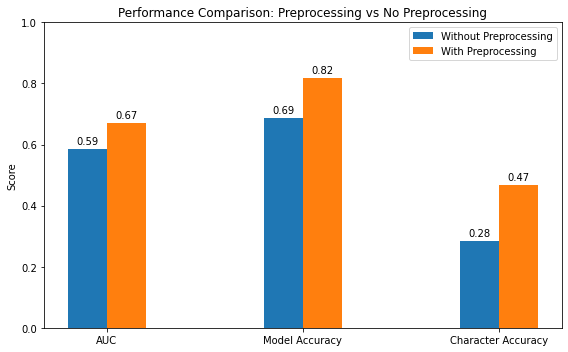

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#Bar Chart to display improvement & IMPACT
labels = ["AUC", "Model Accuracy", "Character Accuracy"]

with_filtering = [
    0.6709039373325087,
      0.8183742183742183,
    0.4666666666666666
]

without_filtering = [
    0.5855331052875695,
    0.6859307359307358,
    0.2848484848484849
]


x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, without_filtering, width, label='Without Preprocessing')
bars2 = ax.bar(x + width/2, with_filtering, width, label='With Preprocessing')

ax.set_ylabel('Score')
ax.set_title('Performance Comparison: Preprocessing vs No Preprocessing')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.legend()

def add_labels(bars):
    for b in bars:
        height = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            height + 0.01,
            f'{height:.2f}',
            ha='center',
            va='bottom'
        )

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

Applying a filtering step consistently improved performance across all metrics — AUC rose from 0.59 to 0.67, Model Accuracy from 0.69 to 0.82, and Character Accuracy from 0.28 to 0.47. This suggests that filtering effectively removes noisy or low-quality samples from the data, allowing the model to learn cleaner patterns and generalize better to the data. 